# Notebook 1 — Exploratory Data Analysis & Dataset Justification
### Diabetic Retinopathy Stage Detection | Computer Vision Coursework

**Targets Rubric Criterion 1 (10 marks): Problem Understanding & Dataset Justification**

> *"Clearly explains diabetic retinopathy and its medical significance; dataset from Kaggle is highly
> relevant; detailed description of classes, image distribution, train/validation/test splits, ethical
> concerns, and dataset limitations."*

**Datasets used (two, attached as Kaggle Inputs):**
1. **APTOS 2019 Blindness Detection** (official Kaggle competition) — 3,662 labelled fundus images at
   their original, variable resolution. This is the **primary/authoritative source**: all class counts,
   splits, and labels used anywhere in this project are drawn from this dataset's `train.csv`.
2. **Diabetic Retinopathy 224x224 Gaussian Filtered** (community Kaggle dataset, by `sovitrath`) — the
   same underlying images, already resized to 224x224 and Gaussian-filtered. This is used as a
   **secondary reference dataset**: to (a) sanity-check that its labels agree with the primary source,
   and (b) show concretely what a published preprocessing pipeline does to the same images, which
   directly informs the preprocessing choices justified in Notebook 2.

**What this notebook does:**
1. Loads the labels and verifies both datasets are attached correctly.
2. Cross-checks that the two datasets' labels agree (label integrity check).
3. Counts and visualises the class distribution (and quantifies the imbalance) from the primary dataset.
4. Displays sample images from every class, and a raw-vs-preprocessed side-by-side comparison.
5. Measures how much image resolution/file size varies across the raw dataset, and contrasts this with
   the fixed resolution of the pre-processed reference dataset.
6. Produces a stratified train / validation / test split (from the primary dataset) and saves it for the
   notebooks that follow (Notebook 2 onward will load `train_split.csv`, `validation_split.csv`,
   `test_split.csv` from `/kaggle/working/`, so the whole 6-notebook pipeline stays consistent).

**Coding standard used throughout:** descriptive names, a plain-English comment before every step,
and a `[CELL N] ...` print statement confirming the outcome of every meaningful operation, numbered
sequentially.


In [1]:
# [CELL 1] -------------------------------------------------------------------
# WHAT: Import every library this notebook needs and configure global display
#       and plotting settings.
# WHY:  Doing this once at the top keeps the rest of the notebook clean and
#       makes it obvious, months later, exactly what this notebook depends on.

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as seaborn_plotting_library
from PIL import Image
from sklearn.model_selection import train_test_split

# A fixed random seed makes the class samples we display and the train/val/test
# split reproducible -- anyone re-running this notebook gets identical results.
GLOBAL_RANDOM_SEED = 42
random.seed(GLOBAL_RANDOM_SEED)
np.random.seed(GLOBAL_RANDOM_SEED)

# Make plots render at a readable size and with a consistent, professional style.
seaborn_plotting_library.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"[CELL 1] Libraries imported successfully. Global random seed fixed at {GLOBAL_RANDOM_SEED}.")


[CELL 1] Libraries imported successfully. Global random seed fixed at 42.


In [2]:
# [CELL 2] -------------------------------------------------------------------
# WHAT: Locate BOTH attached datasets inside /kaggle/input:
#         (1) the primary raw APTOS 2019 competition dataset
#         (2) the secondary pre-resized/Gaussian-filtered reference dataset
#       Kaggle's mount layout has changed over time and can differ between
#       accounts/notebooks (flat /kaggle/input/<slug>/ vs. nested
#       /kaggle/input/competitions/<slug>/ and /kaggle/input/datasets/<owner>/<slug>/),
#       so this checks a short list of candidate paths rather than assuming one.
# WHY:  Hard-coding a single path assumption breaks silently (or loudly) when
#       Kaggle's layout changes. Searching candidates and reporting exactly
#       what was found makes this robust and self-documenting.

def locate_first_existing_directory(candidate_directory_paths, description):
    """Return the first path in candidate_directory_paths that exists as a
    directory, or raise a clear error listing everything that was tried."""
    for candidate_path in candidate_directory_paths:
        if os.path.isdir(candidate_path):
            return candidate_path
    raise FileNotFoundError(
        f"Could not locate the {description}. Tried: {candidate_directory_paths}. "
        f"Run `os.listdir('/kaggle/input')` (and one level deeper) to find the real "
        f"path and add it to the candidate list above."
    )

# --- Primary dataset: raw APTOS 2019 competition data -----------------------
raw_aptos_dataset_candidate_paths = [
    "/kaggle/input/aptos2019-blindness-detection",
    "/kaggle/input/competitions/aptos2019-blindness-detection",
]
raw_aptos_dataset_root_directory = locate_first_existing_directory(
    raw_aptos_dataset_candidate_paths, "raw APTOS 2019 competition dataset"
)
training_labels_csv_path = os.path.join(raw_aptos_dataset_root_directory, "train.csv")
training_images_directory_path = os.path.join(raw_aptos_dataset_root_directory, "train_images")

# --- Secondary dataset: pre-resized / Gaussian-filtered reference data ------
# Community datasets are mounted under /kaggle/input/datasets/<owner>/<slug>/,
# so we search under the known owner folder for any subfolder that actually
# contains the expected contents, instead of guessing the exact slug text.
gaussian_filtered_dataset_root_directory = None
datasets_owner_search_roots = [
    "/kaggle/input",                      # older flat layout
    "/kaggle/input/datasets/sovitrath",    # newer nested layout, known owner
]
for search_root in datasets_owner_search_roots:
    if not os.path.isdir(search_root):
        continue
    for entry_name in os.listdir(search_root):
        entry_path = os.path.join(search_root, entry_name)
        if os.path.isdir(entry_path) and "gaussian_filtered_images" in os.listdir(entry_path):
            gaussian_filtered_dataset_root_directory = entry_path
            break
    if gaussian_filtered_dataset_root_directory is not None:
        break

if gaussian_filtered_dataset_root_directory is None:
    raise FileNotFoundError(
        "Could not locate the Gaussian-filtered reference dataset. Confirm it is "
        "attached as a Kaggle Input, then run `os.listdir('/kaggle/input/datasets/sovitrath')` "
        "to find its exact folder name and adjust this cell."
    )

gaussian_filtered_labels_csv_path = os.path.join(gaussian_filtered_dataset_root_directory, "train.csv")

# The published dataset nests the actual per-class image folders at an
# inconsistent depth (observed: root/gaussian_filtered_images/gaussian_filtered_images/<ClassName>/),
# and mixes in non-image files (e.g. export.pkl) alongside them. Rather than
# assuming a fixed depth, we walk the whole tree and record the path to each
# of the 5 expected class-name folders wherever they actually are.
known_dr_stage_folder_names = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative_DR"]
# Some published copies of this dataset misspell the folder as "Proliferate_DR"
# (missing "-ive") instead of "Proliferative_DR" -- map both spellings to the
# same canonical stage name so matching works regardless of which is used.
stage_name_spelling_variants = {
    "no_dr": "No_DR",
    "mild": "Mild",
    "moderate": "Moderate",
    "severe": "Severe",
    "proliferative_dr": "Proliferative_DR",
    "proliferate_dr": "Proliferative_DR",
}
normalized_stage_name_lookup = stage_name_spelling_variants

gaussian_filtered_class_folder_paths = {}
for current_directory, subdirectory_names, _file_names in os.walk(gaussian_filtered_dataset_root_directory):
    for subdirectory_name in subdirectory_names:
        normalized_name = subdirectory_name.lower()
        if normalized_name in normalized_stage_name_lookup:
            canonical_stage_name = normalized_stage_name_lookup[normalized_name]
            # Keep the first match found; datasets shouldn't have duplicate class folders.
            gaussian_filtered_class_folder_paths.setdefault(
                canonical_stage_name, os.path.join(current_directory, subdirectory_name)
            )

# Valid image file extensions -- used everywhere we list a class folder's
# contents, so stray non-image files (e.g. export.pkl, seen in this dataset)
# are never mistaken for an image.
valid_image_file_extensions = (".png", ".jpg", ".jpeg")

# Sanity-check every path we just resolved before going any further -- this
# fails loudly and early rather than silently producing wrong results later.
labels_file_found = os.path.isfile(training_labels_csv_path)
images_folder_found = os.path.isdir(training_images_directory_path)
gaussian_labels_file_found = os.path.isfile(gaussian_filtered_labels_csv_path)
gaussian_all_class_folders_found = len(gaussian_filtered_class_folder_paths) == len(known_dr_stage_folder_names)

if not (labels_file_found and images_folder_found):
    raise FileNotFoundError(
        f"Found raw dataset root '{raw_aptos_dataset_root_directory}' but train.csv or "
        f"train_images/ is missing inside it. Contents found: "
        f"{os.listdir(raw_aptos_dataset_root_directory)}"
    )
if not (gaussian_labels_file_found and gaussian_all_class_folders_found):
    raise FileNotFoundError(
        f"Found Gaussian-filtered dataset root '{gaussian_filtered_dataset_root_directory}' but "
        f"train.csv is missing or not all 5 class folders were found while walking the tree. "
        f"Class folders found so far: {gaussian_filtered_class_folder_paths}. "
        f"Expected: {known_dr_stage_folder_names}."
    )

print(f"[CELL 2] Located raw APTOS 2019 dataset at '{raw_aptos_dataset_root_directory}' "
      f"(labels found: {labels_file_found}, images folder found: {images_folder_found}).")
print(f"[CELL 2] Located Gaussian-filtered reference dataset at '{gaussian_filtered_dataset_root_directory}' "
      f"(labels found: {gaussian_labels_file_found}).")
for stage_name, folder_path in gaussian_filtered_class_folder_paths.items():
    print(f"[CELL 2]   Class folder '{stage_name}' -> '{folder_path}'")


[CELL 2] Located raw APTOS 2019 dataset at '/kaggle/input/competitions/aptos2019-blindness-detection' (labels found: True, images folder found: True).
[CELL 2] Located Gaussian-filtered reference dataset at '/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered' (labels found: True).
[CELL 2]   Class folder 'Mild' -> '/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Mild'
[CELL 2]   Class folder 'Proliferative_DR' -> '/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Proliferate_DR'
[CELL 2]   Class folder 'Moderate' -> '/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Moderate'
[CELL 2]   Class folder 'No_DR' -> '/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gauss

In [3]:
# [CELL 3] -------------------------------------------------------------------
# WHAT: Load the training labels CSV into a pandas DataFrame.
# WHY:  train.csv is the single source of truth linking each image filename
#       (id_code) to its ground-truth DR severity grade (diagnosis). Every
#       later step -- class counts, sample display, splitting -- is driven
#       from this table, not from scanning the image folder directly.

diabetic_retinopathy_training_labels_dataframe = pd.read_csv(training_labels_csv_path)

total_number_of_labelled_images = len(diabetic_retinopathy_training_labels_dataframe)
number_of_distinct_diagnosis_classes = diabetic_retinopathy_training_labels_dataframe["diagnosis"].nunique()

print(f"[CELL 3] Loaded training dataset: {total_number_of_labelled_images:,} images "
      f"across {number_of_distinct_diagnosis_classes} classes.")
diabetic_retinopathy_training_labels_dataframe.head()


[CELL 3] Loaded training dataset: 3,662 images across 5 classes.


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [4]:
# [CELL 4] -------------------------------------------------------------------
# WHAT: Map the raw numeric diagnosis codes (0-4) to human-readable DR stage
#       names, and add this as a new column.
# WHY:  Numeric codes alone (0,1,2,3,4) are meaningless without the mapping
#       and easy to misreport in the write-up. Attaching descriptive names
#       directly to the DataFrame means every downstream plot, table and
#       print statement can show the real clinical stage name.

dr_severity_stage_label_mapping = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative_DR",
}

diabetic_retinopathy_training_labels_dataframe["diagnosis_stage_name"] = (
    diabetic_retinopathy_training_labels_dataframe["diagnosis"].map(dr_severity_stage_label_mapping)
)

print("[CELL 4] Mapped numeric diagnosis codes to descriptive DR stage names:")
for numeric_code, stage_name in dr_severity_stage_label_mapping.items():
    print(f"          {numeric_code} -> {stage_name}")


[CELL 4] Mapped numeric diagnosis codes to descriptive DR stage names:
          0 -> No_DR
          1 -> Mild
          2 -> Moderate
          3 -> Severe
          4 -> Proliferative_DR


In [5]:
# [CELL 5] -------------------------------------------------------------------
# WHAT: Load the Gaussian-filtered reference dataset's own train.csv and check
#       that its diagnosis labels agree with the primary raw dataset's labels
#       for the same id_code.
# WHY:  We are about to rely on a second, community-published dataset as a
#       preprocessing reference in later cells. Before trusting it at all, we
#       should verify it is genuinely the same labelled data and not a
#       different split, a relabelled version, or otherwise inconsistent --
#       this is basic due diligence for dataset justification, not just
#       description.

gaussian_filtered_training_labels_dataframe = pd.read_csv(gaussian_filtered_labels_csv_path)

merged_labels_for_consistency_check_dataframe = diabetic_retinopathy_training_labels_dataframe.merge(
    gaussian_filtered_training_labels_dataframe,
    on="id_code",
    how="inner",
    suffixes=("_raw_dataset", "_gaussian_dataset"),
)

number_of_ids_present_in_both_datasets = len(merged_labels_for_consistency_check_dataframe)
number_of_label_mismatches_between_datasets = int(
    (
        merged_labels_for_consistency_check_dataframe["diagnosis_raw_dataset"]
        != merged_labels_for_consistency_check_dataframe["diagnosis_gaussian_dataset"]
    ).sum()
)

print(f"[CELL 5] Loaded Gaussian-filtered reference dataset labels: "
      f"{len(gaussian_filtered_training_labels_dataframe):,} rows.")
print(f"[CELL 5] Matched {number_of_ids_present_in_both_datasets:,} id_codes present in BOTH datasets.")
print(f"[CELL 5] Label mismatches between raw and Gaussian-filtered datasets for matched ids: "
      f"{number_of_label_mismatches_between_datasets} "
      f"({'CONSISTENT -- safe to use as a reference dataset' if number_of_label_mismatches_between_datasets == 0 else 'INCONSISTENT -- investigate before relying on this dataset'}).")


[CELL 5] Loaded Gaussian-filtered reference dataset labels: 3,662 rows.
[CELL 5] Matched 3,662 id_codes present in BOTH datasets.
[CELL 5] Label mismatches between raw and Gaussian-filtered datasets for matched ids: 0 (CONSISTENT -- safe to use as a reference dataset).


In [6]:
# [CELL 6] -------------------------------------------------------------------
# WHAT: Count how many images fall into each DR severity class, and express
#       each count as a percentage of the full dataset.
# WHY:  This is the core evidence for the rubric's "detailed description of
#       classes [and] image distribution" requirement, and it is what tells
#       us -- objectively, not just by assumption -- whether the dataset is
#       imbalanced and by how much.

class_distribution_counts_series = (
    diabetic_retinopathy_training_labels_dataframe["diagnosis"]
    .value_counts()
    .sort_index()
)
class_distribution_percentage_series = (
    class_distribution_counts_series / total_number_of_labelled_images * 100
)

class_distribution_summary_dataframe = pd.DataFrame({
    "diagnosis_code": class_distribution_counts_series.index,
    "diagnosis_stage_name": [dr_severity_stage_label_mapping[code] for code in class_distribution_counts_series.index],
    "image_count": class_distribution_counts_series.values,
    "percentage_of_dataset": class_distribution_percentage_series.values.round(2),
})

print("[CELL 6] Class distribution across the full training dataset:")
for _, row in class_distribution_summary_dataframe.iterrows():
    print(f"          Class {row['diagnosis_code']} ({row['diagnosis_stage_name']:>17}): "
          f"{row['image_count']:>5,} images  ({row['percentage_of_dataset']:>5.2f}%)")

class_distribution_summary_dataframe


[CELL 6] Class distribution across the full training dataset:
          Class 0 (            No_DR): 1,805 images  (49.29%)
          Class 1 (             Mild):   370 images  (10.10%)
          Class 2 (         Moderate):   999 images  (27.28%)
          Class 3 (           Severe):   193 images  ( 5.27%)
          Class 4 ( Proliferative_DR):   295 images  ( 8.06%)


,diagnosis_code,diagnosis_stage_name,image_count,percentage_of_dataset
0,0,No_DR,1805,49.29
1,1,Mild,370,10.10
2,2,Moderate,999,27.28
3,3,Severe,193,5.27
4,4,Proliferative_DR,295,8.06


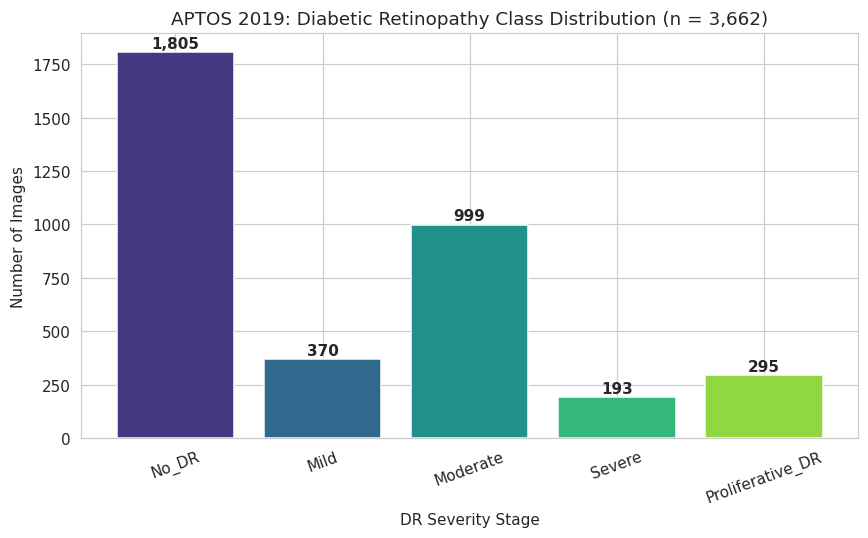

[CELL 7] Saved class distribution bar chart to '/kaggle/working/class_distribution_bar_chart.png'.


In [7]:
# [CELL 7] -------------------------------------------------------------------
# WHAT: Visualise the class distribution as a bar chart.
# WHY:  A bar chart makes the imbalance immediately visible to a reader --
#       far more effective for the report than a table of numbers alone --
#       and it is one of the required pieces of graphic evidence.

figure, axis = plt.subplots(figsize=(8, 5))
bar_chart_colors = seaborn_plotting_library.color_palette("viridis", n_colors=5)

axis.bar(
    class_distribution_summary_dataframe["diagnosis_stage_name"],
    class_distribution_summary_dataframe["image_count"],
    color=bar_chart_colors,
)
axis.set_title("APTOS 2019: Diabetic Retinopathy Class Distribution (n = 3,662)")
axis.set_xlabel("DR Severity Stage")
axis.set_ylabel("Number of Images")
plt.xticks(rotation=20)

for bar_index, image_count in enumerate(class_distribution_summary_dataframe["image_count"]):
    axis.text(bar_index, image_count + 20, f"{image_count:,}", ha="center", fontweight="bold")

plt.tight_layout()
class_distribution_chart_output_path = "/kaggle/working/class_distribution_bar_chart.png"
plt.savefig(class_distribution_chart_output_path)
plt.show()

print(f"[CELL 7] Saved class distribution bar chart to '{class_distribution_chart_output_path}'.")


In [8]:
# [CELL 8] -------------------------------------------------------------------
# WHAT: Quantify the class imbalance as a ratio between the largest and
#       smallest classes.
# WHY:  "The dataset looks imbalanced" is a weak, vague claim for a report
#       aiming at the Excellent band. Reporting the exact ratio, and naming
#       the majority/minority classes, is precise evidence the rubric
#       rewards -- and it directly motivates the augmentation and
#       class-weighting work planned for Notebook 3.

majority_class_row = class_distribution_summary_dataframe.loc[
    class_distribution_summary_dataframe["image_count"].idxmax()
]
minority_class_row = class_distribution_summary_dataframe.loc[
    class_distribution_summary_dataframe["image_count"].idxmin()
]
class_imbalance_ratio = majority_class_row["image_count"] / minority_class_row["image_count"]

print(f"[CELL 8] Class imbalance ratio: largest class '{majority_class_row['diagnosis_stage_name']}' "
      f"({majority_class_row['image_count']:,} images) is {class_imbalance_ratio:.2f}x larger than "
      f"smallest class '{minority_class_row['diagnosis_stage_name']}' ({minority_class_row['image_count']:,} images).")


[CELL 8] Class imbalance ratio: largest class 'No_DR' (1,805 images) is 9.35x larger than smallest class 'Severe' (193 images).


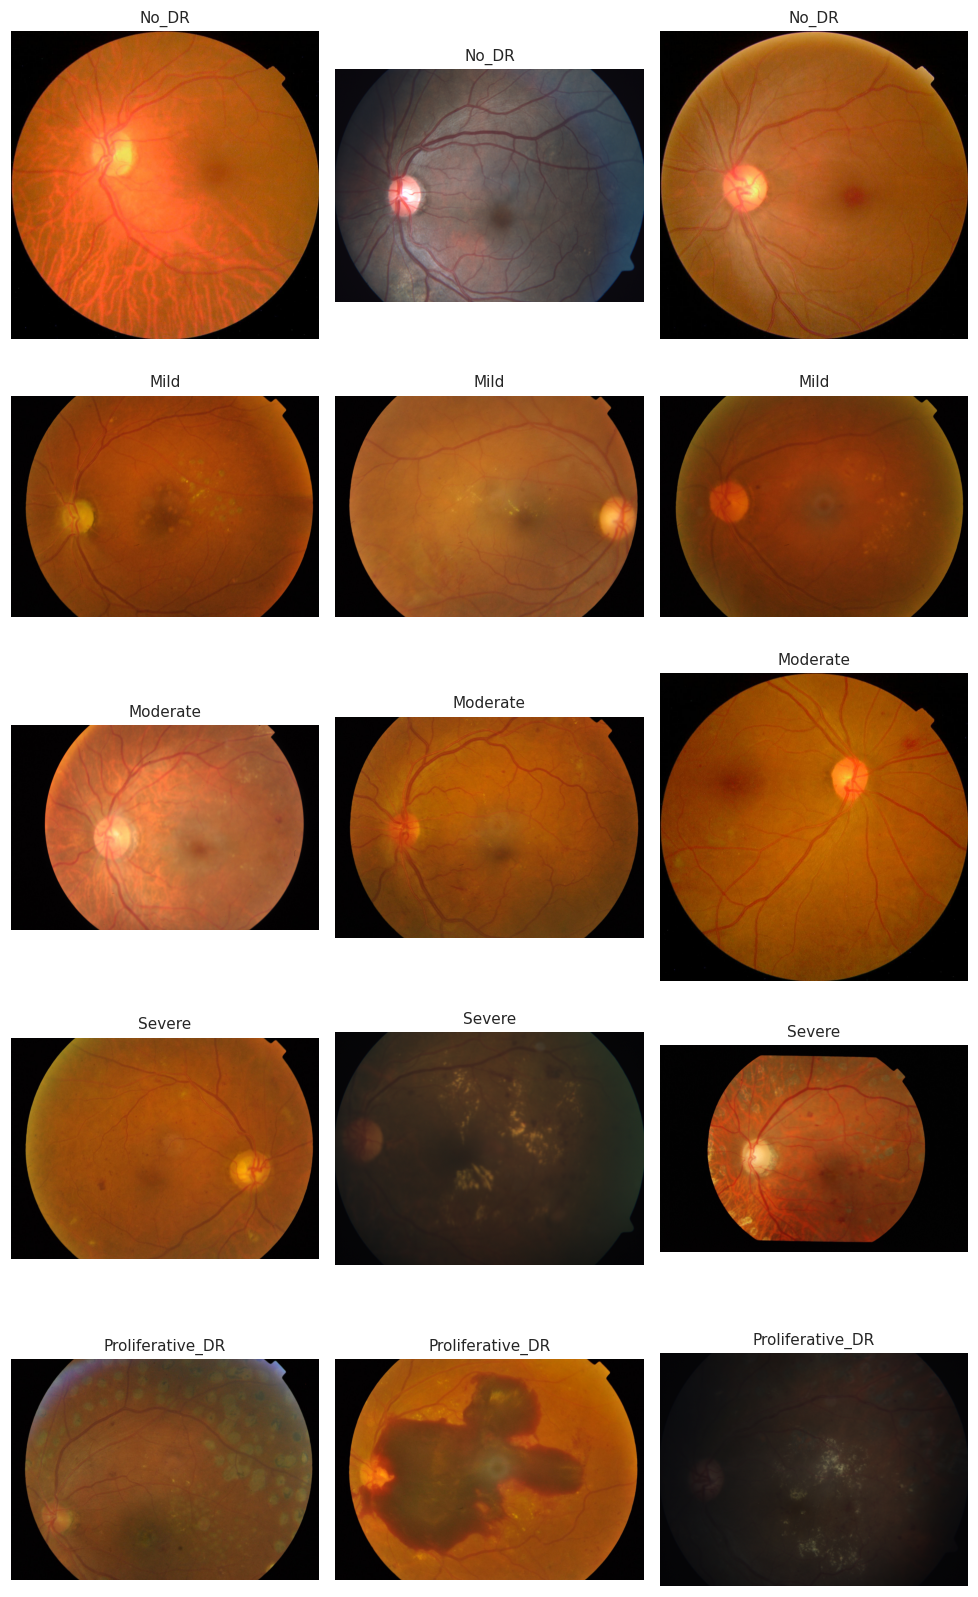

[CELL 9] Displayed 3 raw sample images for each of the 5 classes and saved the grid to '/kaggle/working/sample_images_per_class.png'.


In [9]:
# [CELL 9] -------------------------------------------------------------------
# WHAT: Display a small grid of real sample fundus images from each of the
#       5 classes, from the RAW (unprocessed) dataset.
# WHY:  Numbers alone don't demonstrate visual understanding of the problem.
#       Showing actual images -- and being able to say, in the video, "here
#       is what Moderate DR looks like versus No DR" -- is direct evidence
#       for "clearly explains diabetic retinopathy" in the rubric, and it is
#       required graphic evidence for the report.

number_of_sample_images_per_class = 3
diagnosis_codes_in_order = sorted(dr_severity_stage_label_mapping.keys())

figure, axis_grid = plt.subplots(
    nrows=len(diagnosis_codes_in_order),
    ncols=number_of_sample_images_per_class,
    figsize=(number_of_sample_images_per_class * 3, len(diagnosis_codes_in_order) * 3),
)

for row_index, diagnosis_code in enumerate(diagnosis_codes_in_order):
    image_ids_for_this_class = (
        diabetic_retinopathy_training_labels_dataframe
        .loc[diabetic_retinopathy_training_labels_dataframe["diagnosis"] == diagnosis_code, "id_code"]
        .sample(n=number_of_sample_images_per_class, random_state=GLOBAL_RANDOM_SEED)
        .tolist()
    )
    for column_index, image_id in enumerate(image_ids_for_this_class):
        image_file_path = os.path.join(training_images_directory_path, f"{image_id}.png")
        sample_image_array = mpimg.imread(image_file_path)
        current_axis = axis_grid[row_index, column_index]
        current_axis.imshow(sample_image_array)
        current_axis.axis("off")
        current_axis.set_title(dr_severity_stage_label_mapping[diagnosis_code], fontsize=10)

plt.tight_layout()
sample_images_grid_output_path = "/kaggle/working/sample_images_per_class.png"
plt.savefig(sample_images_grid_output_path)
plt.show()

print(f"[CELL 9] Displayed {number_of_sample_images_per_class} raw sample images for each of the "
      f"{len(diagnosis_codes_in_order)} classes and saved the grid to '{sample_images_grid_output_path}'.")


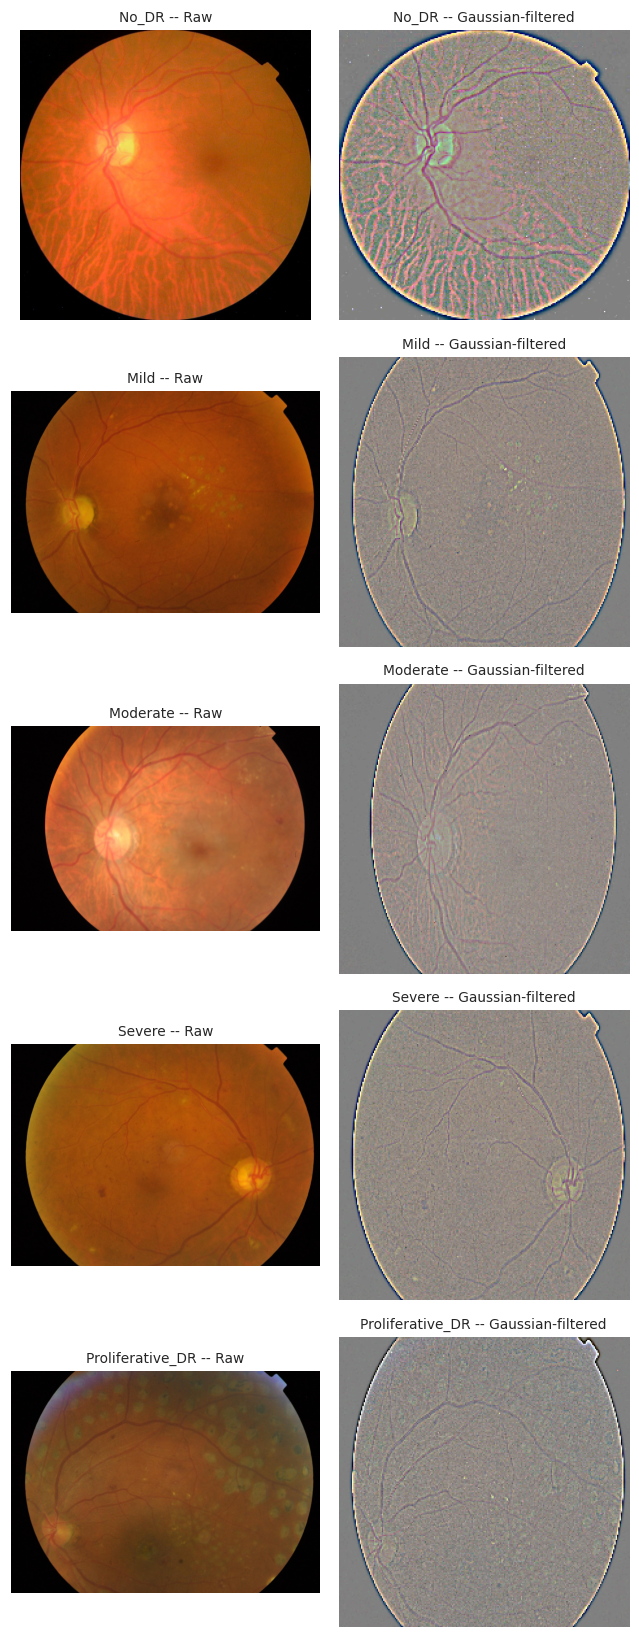

[CELL 10] Built raw-vs-Gaussian-filtered comparison for 5/5 classes and saved to '/kaggle/working/raw_vs_gaussian_filtered_comparison.png'.


In [10]:
# [CELL 10] ------------------------------------------------------------------
# WHAT: For one sample image per class, display the RAW version next to the
#       Gaussian-filtered reference-dataset version, side by side.
# WHY:  This turns "we used a Gaussian-filtered reference dataset" from a
#       throwaway line into visible evidence of exactly what that published
#       preprocessing pipeline does (contrast enhancement, circular cropping,
#       colour normalisation), which directly supports and motivates the
#       preprocessing decisions that will be justified in Notebook 2.
# NOTE: We already know each image's class from the labels dataframe, so we
#       look directly inside that class's folder (found in Cell 2) rather
#       than searching every class folder for a filename match.

def find_gaussian_filtered_image_path(image_id, diagnosis_stage_name):
    """Return the full path to image_id inside its own class's Gaussian-filtered
    folder, trying each valid image extension, or None if not found."""
    class_folder_path = gaussian_filtered_class_folder_paths.get(diagnosis_stage_name)
    if class_folder_path is None:
        return None
    for extension in valid_image_file_extensions:
        candidate_path = os.path.join(class_folder_path, f"{image_id}{extension}")
        if os.path.isfile(candidate_path):
            return candidate_path
    return None

figure, axis_grid = plt.subplots(nrows=len(diagnosis_codes_in_order), ncols=2, figsize=(6, len(diagnosis_codes_in_order) * 3))
number_of_successful_comparison_pairs = 0

for row_index, diagnosis_code in enumerate(diagnosis_codes_in_order):
    diagnosis_stage_name = dr_severity_stage_label_mapping[diagnosis_code]
    candidate_image_ids = (
        diabetic_retinopathy_training_labels_dataframe
        .loc[diabetic_retinopathy_training_labels_dataframe["diagnosis"] == diagnosis_code, "id_code"]
        .sample(frac=1.0, random_state=GLOBAL_RANDOM_SEED)
        .tolist()
    )
    raw_image_array, gaussian_image_array, matched_image_id = None, None, None
    for candidate_id in candidate_image_ids:
        gaussian_path = find_gaussian_filtered_image_path(candidate_id, diagnosis_stage_name)
        if gaussian_path is not None:
            raw_image_array = mpimg.imread(os.path.join(training_images_directory_path, f"{candidate_id}.png"))
            gaussian_image_array = mpimg.imread(gaussian_path)
            matched_image_id = candidate_id
            break

    left_axis, right_axis = axis_grid[row_index, 0], axis_grid[row_index, 1]
    if matched_image_id is not None:
        left_axis.imshow(raw_image_array)
        right_axis.imshow(gaussian_image_array)
        number_of_successful_comparison_pairs += 1
    left_axis.set_title(f"{dr_severity_stage_label_mapping[diagnosis_code]} -- Raw", fontsize=9)
    right_axis.set_title(f"{dr_severity_stage_label_mapping[diagnosis_code]} -- Gaussian-filtered", fontsize=9)
    left_axis.axis("off")
    right_axis.axis("off")

plt.tight_layout()
raw_vs_gaussian_comparison_output_path = "/kaggle/working/raw_vs_gaussian_filtered_comparison.png"
plt.savefig(raw_vs_gaussian_comparison_output_path)
plt.show()

print(f"[CELL 10] Built raw-vs-Gaussian-filtered comparison for "
      f"{number_of_successful_comparison_pairs}/{len(diagnosis_codes_in_order)} classes "
      f"and saved to '{raw_vs_gaussian_comparison_output_path}'.")


In [11]:
# [CELL 11] ------------------------------------------------------------------
# WHAT: Open a random subset of RAW images and record their width, height and
#       file size, then summarise how much these vary across the dataset.
# WHY:  The rubric explicitly asks for a description of "image distribution"
#       and dataset limitations. Fundus cameras in different clinics produce
#       images at different resolutions and aspect ratios -- this directly
#       justifies the resizing/normalisation step planned for the
#       preprocessing notebook, so it needs to be measured here, not assumed.

number_of_images_to_sample_for_resolution_check = 300
sampled_image_ids_for_resolution_check = (
    diabetic_retinopathy_training_labels_dataframe["id_code"]
    .sample(n=number_of_images_to_sample_for_resolution_check, random_state=GLOBAL_RANDOM_SEED)
    .tolist()
)

recorded_image_widths_in_pixels = []
recorded_image_heights_in_pixels = []
recorded_image_file_sizes_in_kilobytes = []

for image_id in sampled_image_ids_for_resolution_check:
    image_file_path = os.path.join(training_images_directory_path, f"{image_id}.png")
    with Image.open(image_file_path) as opened_image:
        image_width_pixels, image_height_pixels = opened_image.size
    recorded_image_widths_in_pixels.append(image_width_pixels)
    recorded_image_heights_in_pixels.append(image_height_pixels)
    recorded_image_file_sizes_in_kilobytes.append(os.path.getsize(image_file_path) / 1024)

image_resolution_summary_dataframe = pd.DataFrame({
    "width_pixels": recorded_image_widths_in_pixels,
    "height_pixels": recorded_image_heights_in_pixels,
    "file_size_kilobytes": recorded_image_file_sizes_in_kilobytes,
})

print(f"[CELL 11] Measured resolution/file size across a random sample of "
      f"{number_of_images_to_sample_for_resolution_check} RAW images:")
print(f"           Width  (px): min={image_resolution_summary_dataframe['width_pixels'].min()}, "
      f"max={image_resolution_summary_dataframe['width_pixels'].max()}, "
      f"mean={image_resolution_summary_dataframe['width_pixels'].mean():.0f}, "
      f"std={image_resolution_summary_dataframe['width_pixels'].std():.0f}")
print(f"           Height (px): min={image_resolution_summary_dataframe['height_pixels'].min()}, "
      f"max={image_resolution_summary_dataframe['height_pixels'].max()}, "
      f"mean={image_resolution_summary_dataframe['height_pixels'].mean():.0f}, "
      f"std={image_resolution_summary_dataframe['height_pixels'].std():.0f}")
print(f"           File size (KB): min={image_resolution_summary_dataframe['file_size_kilobytes'].min():.0f}, "
      f"max={image_resolution_summary_dataframe['file_size_kilobytes'].max():.0f}, "
      f"mean={image_resolution_summary_dataframe['file_size_kilobytes'].mean():.0f}")

number_of_unique_resolutions_found = image_resolution_summary_dataframe.drop_duplicates(
    subset=["width_pixels", "height_pixels"]
).shape[0]
print(f"           Found {number_of_unique_resolutions_found} distinct (width, height) resolutions "
      f"among the {number_of_images_to_sample_for_resolution_check} RAW images sampled -- "
      f"confirming resolution is NOT fixed and must be standardised during preprocessing.")


[CELL 11] Measured resolution/file size across a random sample of 300 RAW images:
           Width  (px): min=474, max=4288, mean=2017, std=912
           Height (px): min=358, max=2848, mean=1534, std=557
           File size (KB): min=217, max=7291, mean=2327
           Found 15 distinct (width, height) resolutions among the 300 RAW images sampled -- confirming resolution is NOT fixed and must be standardised during preprocessing.


In [12]:
# [CELL 12] ------------------------------------------------------------------
# WHAT: Open a random sample of images from the Gaussian-filtered reference
#       dataset and confirm they are all a single, fixed resolution.
# WHY:  This is the direct contrast to Cell 11: it proves the secondary
#       dataset represents ONE valid published choice of standardised target
#       size (224x224), which is useful evidence when we justify our own
#       target resolution choice in Notebook 2, rather than picking a number
#       with no comparison point.

number_of_gaussian_images_to_sample = 100
sampled_gaussian_image_paths = []
for class_folder_path in gaussian_filtered_class_folder_paths.values():
    # Only collect files with a recognised image extension -- this dataset
    # mixes in non-image files (e.g. export.pkl) alongside the class images,
    # which would otherwise crash Image.open().
    image_file_names_in_this_folder = [
        file_name for file_name in os.listdir(class_folder_path)
        if file_name.lower().endswith(valid_image_file_extensions)
    ]
    for file_name in image_file_names_in_this_folder[:20]:
        sampled_gaussian_image_paths.append(os.path.join(class_folder_path, file_name))

random.shuffle(sampled_gaussian_image_paths)
sampled_gaussian_image_paths = sampled_gaussian_image_paths[:number_of_gaussian_images_to_sample]

gaussian_image_resolutions_found = set()
for image_path in sampled_gaussian_image_paths:
    with Image.open(image_path) as opened_image:
        gaussian_image_resolutions_found.add(opened_image.size)

print(f"[CELL 12] Checked {len(sampled_gaussian_image_paths)} images from the Gaussian-filtered "
      f"reference dataset -- distinct resolutions found: {gaussian_image_resolutions_found}.")
print(f"[CELL 12] Contrast with Cell 11: the raw dataset has many resolutions; this reference "
      f"dataset standardises every image to a single fixed size, confirming 224x224 is a "
      f"realistic, previously-used target size for our own preprocessing pipeline.")


[CELL 12] Checked 100 images from the Gaussian-filtered reference dataset -- distinct resolutions found: {(224, 224)}.
[CELL 12] Contrast with Cell 11: the raw dataset has many resolutions; this reference dataset standardises every image to a single fixed size, confirming 224x224 is a realistic, previously-used target size for our own preprocessing pipeline.


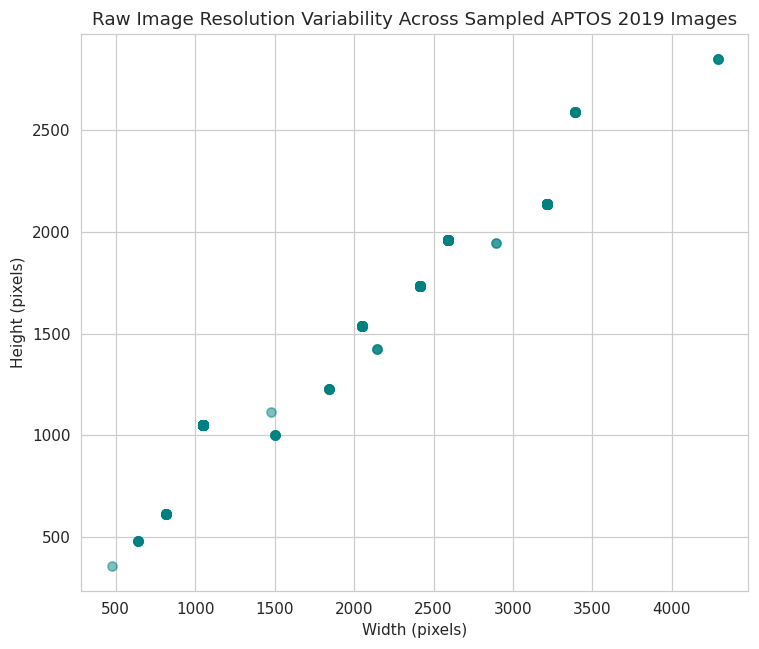

[CELL 13] Saved resolution variability scatter plot to '/kaggle/working/image_resolution_variability_scatter.png'.


In [13]:
# [CELL 13] ------------------------------------------------------------------
# WHAT: Plot every sampled RAW image's width against its height as a scatter
#       plot.
# WHY:  This turns the min/max/mean numbers from Cell 11 into a single figure
#       that visually shows both the spread of resolutions and the mix of
#       aspect ratios present in the dataset -- useful supporting evidence
#       for the report's preprocessing justification section.

figure, axis = plt.subplots(figsize=(7, 6))
axis.scatter(
    image_resolution_summary_dataframe["width_pixels"],
    image_resolution_summary_dataframe["height_pixels"],
    alpha=0.5,
    color="teal",
)
axis.set_title("Raw Image Resolution Variability Across Sampled APTOS 2019 Images")
axis.set_xlabel("Width (pixels)")
axis.set_ylabel("Height (pixels)")
plt.tight_layout()
resolution_scatter_plot_output_path = "/kaggle/working/image_resolution_variability_scatter.png"
plt.savefig(resolution_scatter_plot_output_path)
plt.show()

print(f"[CELL 13] Saved resolution variability scatter plot to '{resolution_scatter_plot_output_path}'.")


In [14]:
# [CELL 14] ------------------------------------------------------------------
# WHAT: Create a stratified 70% train / 15% validation / 15% test split, from
#       the PRIMARY (raw) dataset's labels.
# WHY:  A plain random split risks putting almost none of the rare Severe or
#       Proliferative DR images into the validation/test sets, making later
#       evaluation unreliable. Stratifying on 'diagnosis' guarantees every
#       split preserves (as closely as possible) the same class proportions
#       as the full dataset -- this is the split every later notebook in the
#       pipeline (preprocessing, augmentation, training, evaluation) will use,
#       so it is fixed here, once, with a fixed random seed for reproducibility.

train_and_validation_subset_dataframe, test_subset_dataframe = train_test_split(
    diabetic_retinopathy_training_labels_dataframe,
    test_size=0.15,
    stratify=diabetic_retinopathy_training_labels_dataframe["diagnosis"],
    random_state=GLOBAL_RANDOM_SEED,
)

validation_fraction_of_remaining_data = 0.15 / 0.85
train_subset_dataframe, validation_subset_dataframe = train_test_split(
    train_and_validation_subset_dataframe,
    test_size=validation_fraction_of_remaining_data,
    stratify=train_and_validation_subset_dataframe["diagnosis"],
    random_state=GLOBAL_RANDOM_SEED,
)

print("[CELL 14] Created stratified train/validation/test split (from the primary raw dataset):")
print(f"           Train:      {len(train_subset_dataframe):>5,} images "
      f"({len(train_subset_dataframe) / total_number_of_labelled_images * 100:.1f}%)")
print(f"           Validation: {len(validation_subset_dataframe):>5,} images "
      f"({len(validation_subset_dataframe) / total_number_of_labelled_images * 100:.1f}%)")
print(f"           Test:       {len(test_subset_dataframe):>5,} images "
      f"({len(test_subset_dataframe) / total_number_of_labelled_images * 100:.1f}%)")
print(f"           Total:      {len(train_subset_dataframe) + len(validation_subset_dataframe) + len(test_subset_dataframe):>5,} images")


[CELL 14] Created stratified train/validation/test split (from the primary raw dataset):
           Train:      2,562 images (70.0%)
           Validation:   550 images (15.0%)
           Test:         550 images (15.0%)
           Total:      3,662 images


In [15]:
# [CELL 15] ------------------------------------------------------------------
# WHAT: Check that the class proportions in each split closely match the
#       class proportions in the full dataset.
# WHY:  This is the direct proof that the stratified split worked as
#       intended -- important evidence to include in the report, since simply
#       claiming "the split is stratified" is weaker than showing it.

split_name_to_dataframe = {
    "Full dataset": diabetic_retinopathy_training_labels_dataframe,
    "Train split": train_subset_dataframe,
    "Validation split": validation_subset_dataframe,
    "Test split": test_subset_dataframe,
}

stratification_check_rows = []
for split_name, split_dataframe in split_name_to_dataframe.items():
    class_percentages_for_this_split = (
        split_dataframe["diagnosis"].value_counts(normalize=True).sort_index() * 100
    )
    stratification_check_rows.append(class_percentages_for_this_split.rename(split_name))

stratification_check_dataframe = pd.concat(stratification_check_rows, axis=1).round(2)
stratification_check_dataframe.index = [dr_severity_stage_label_mapping[code] for code in stratification_check_dataframe.index]

print("[CELL 15] Class percentage comparison across full dataset vs. each split (stratification check):")
print(stratification_check_dataframe.to_string())
stratification_check_dataframe


[CELL 15] Class percentage comparison across full dataset vs. each split (stratification check):
                  Full dataset  Train split  Validation split  Test split
No_DR                    49.29        49.30             49.27       49.27
Mild                     10.10        10.07             10.18       10.18
Moderate                 27.28        27.28             27.27       27.27
Severe                    5.27         5.27              5.27        5.27
Proliferative_DR          8.06         8.08              8.00        8.00


,Full dataset,Train split,Validation split,Test split
No_DR,49.29,49.30,49.27,49.27
Mild,10.10,10.07,10.18,10.18
Moderate,27.28,27.28,27.27,27.27
Severe,5.27,5.27,5.27,5.27
Proliferative_DR,8.06,8.08,8.00,8.00


In [16]:
# [CELL 16] ------------------------------------------------------------------
# WHAT: Save the three split DataFrames to CSV files in /kaggle/working/.
# WHY:  This notebook is Notebook 1 of a 6-notebook chained pipeline.
#       Persisting the exact split here -- and only here -- means every later
#       notebook (preprocessing, augmentation, model training, evaluation)
#       loads the SAME train/val/test assignment, which is essential for
#       valid, comparable evaluation results later in the project.

train_split_output_path = "/kaggle/working/train_split.csv"
validation_split_output_path = "/kaggle/working/validation_split.csv"
test_split_output_path = "/kaggle/working/test_split.csv"

train_subset_dataframe.to_csv(train_split_output_path, index=False)
validation_subset_dataframe.to_csv(validation_split_output_path, index=False)
test_subset_dataframe.to_csv(test_split_output_path, index=False)

print(f"[CELL 16] Saved train split ({len(train_subset_dataframe):,} rows) to '{train_split_output_path}'.")
print(f"[CELL 16] Saved validation split ({len(validation_subset_dataframe):,} rows) to '{validation_split_output_path}'.")
print(f"[CELL 16] Saved test split ({len(test_subset_dataframe):,} rows) to '{test_split_output_path}'.")
print("[CELL 16] Notebook 1 complete -- outputs ready for Notebook 2 (Preprocessing).")


[CELL 16] Saved train split (2,562 rows) to '/kaggle/working/train_split.csv'.
[CELL 16] Saved validation split (550 rows) to '/kaggle/working/validation_split.csv'.
[CELL 16] Saved test split (550 rows) to '/kaggle/working/test_split.csv'.
[CELL 16] Notebook 1 complete -- outputs ready for Notebook 2 (Preprocessing).


## Summary of evidence produced by this notebook (map to Criterion 1)

| Rubric requirement | Produced by |
|---|---|
| Explains DR and its medical significance | Written report section (see accompanying markdown file) |
| Dataset from Kaggle is highly relevant | Cells 1–5 (direct load from two attached Kaggle datasets, cross-checked for label consistency) |
| Detailed description of classes | Cells 4, 6 |
| Image distribution | Cells 6–8 (counts, percentages, imbalance ratio) + Cell 7 chart |
| Preprocessing justification material | Cells 10, 12 (raw vs. Gaussian-filtered comparison and resolution contrast) |
| Train/validation/test splits | Cells 14–16 (stratified split, verified, saved for the pipeline) |
| Ethical concerns | Written report section |
| Dataset limitations | Cells 11, 13 (resolution variability) + written report section |

**Next notebook in the pipeline:** Notebook 2 — Data Preprocessing (Criterion 2), which will load
`train_split.csv`, `validation_split.csv` and `test_split.csv` saved above.
